In [3]:
import pandas as pd 
import os
os.getcwd()

'/Users/joycelynwilliams/dataanalytics/2026-04-06-Assignment1'

source /Users/joycelynwilliams/dataanalytics/.venv/bin/activate

In [4]:
df = pd.read_csv('/Users/joycelynwilliams/Documents/Assignments/drugs-data.csv')
df.head()

,Drug-1,Drug-2,Drug-3
0,10.1,8.4,20.1
1,11.7,6.9,10.9
2,13.3,20.1,20.1
3,11.7,8.4,14.6
4,10.3,14.5,11.8


In [5]:
# Double check what's in the df first
print(df.columns.tolist())
print(df.shape)

['Drug-1', 'Drug-2', 'Drug-3']
(48, 3)


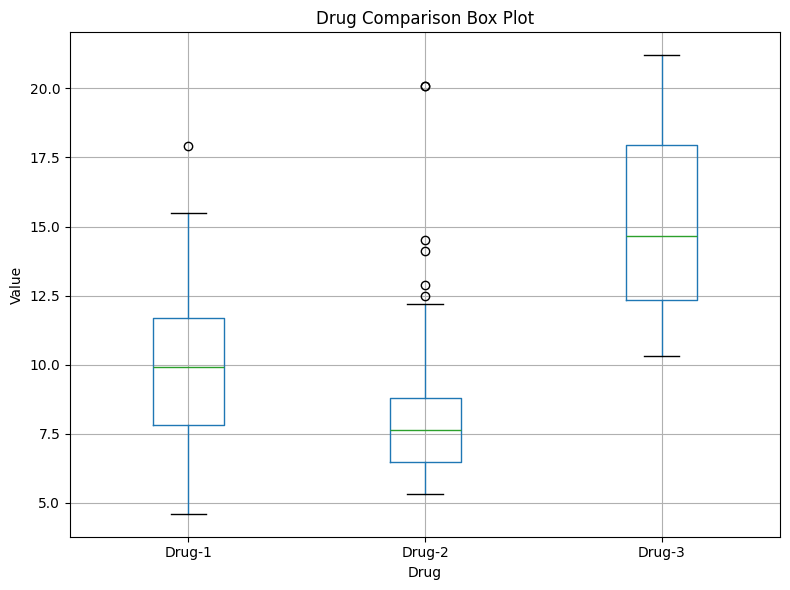

In [6]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df[['Drug-1', 'Drug-2', 'Drug-3']].boxplot(figsize=(8, 6))
plt.title('Drug Comparison Box Plot')
plt.ylabel('Value')
plt.xlabel('Drug')
plt.tight_layout()
plt.show()




In [21]:
import numpy as np
from scipy.stats import norm, kurtosis
data1 = df['Drug-1']  # Replace with the appropriate column name
data2 = df['Drug-2'] 
data3 = df['Drug-3']  

print("The kurtosis value of Drug-1 is:", kurtosis(data1))
print("The kurtosis value of Drug-2 is:", kurtosis(data2))
print("The kurtosis value of Drug-3 is:", kurtosis(data3))

The kurtosis value of Drug-1 is: 0.03054113223023558
The kurtosis value of Drug-2 is: 4.34845608224872
The kurtosis value of Drug-3 is: -1.2166985245389756


In [23]:
import numpy as np

df_long = df.melt(var_name="condition", value_name="value")

results = {}

for cond, group in df_long.groupby("condition"):
    vals = group["value"].values
    results[cond] = {
        "mean": np.mean(vals),
        "median": np.median(vals),
        "std": np.std(vals, ddof=1),
        "Q1": np.percentile(vals, 25),
        "Q2": np.percentile(vals, 50),
        "Q3": np.percentile(vals, 75)
    }

stats = pd.DataFrame(results).T
print(stats)

             mean  median       std      Q1     Q2     Q3
Drug-1   9.929167    9.90  2.779404   7.800   9.90  11.70
Drug-2   8.602083    7.65  3.267082   6.475   7.65   8.80
Drug-3  15.312500   14.65  3.183844  12.350  14.65  17.95


In [40]:
from scipy.stats import shapiro

for cond in df_long["condition"].unique():
    stat, p = shapiro(df_long[df_long["condition"] == cond]["value"])
    print(f"{cond}: p={p}")

Drug-1: p=0.49314353041848263
Drug-2: p=1.2931965147716106e-07
Drug-3: p=0.014390517453377907


In [25]:
from scipy.stats import shapiro
import time

for cond, group in df_long.groupby("condition"):
    print(f"\nRunning Shapiro-Wilk test for: {cond}...")
    time.sleep(0.5)  # optional: makes it feel "live"

    stat, p = shapiro(group["value"])

    print(f"Test statistic: {stat:.4f}")
    print(f"P-value: {p:.4f}")

    # Interpretation logic
    if p > 0.05:
        print("Interpretation: Data looks NORMAL (fail to reject H0)")
        print("→ You can consider PARAMETRIC tests (more power)")
    else:
        print("Interpretation: Data is NOT normal (reject H0)")
        print("→ Use NON-PARAMETRIC tests (safer)")

    print("-" * 50)


Running Shapiro-Wilk test for: Drug-1...
Test statistic: 0.9779
P-value: 0.4931
Interpretation: Data looks NORMAL (fail to reject H0)
→ You can consider PARAMETRIC tests (more power)
--------------------------------------------------

Running Shapiro-Wilk test for: Drug-2...
Test statistic: 0.7528
P-value: 0.0000
Interpretation: Data is NOT normal (reject H0)
→ Use NON-PARAMETRIC tests (safer)
--------------------------------------------------

Running Shapiro-Wilk test for: Drug-3...
Test statistic: 0.9386
P-value: 0.0144
Interpretation: Data is NOT normal (reject H0)
→ Use NON-PARAMETRIC tests (safer)
--------------------------------------------------


In [29]:
import numpy as np
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(df['Drug-1'], df['Drug-2'], df['Drug-3'])
print(p)

1.0414308490857518e-12


In [38]:
%pip install statsmodels
from scipy.stats import wilcoxon
from itertools import combinations

conditions = ["Drug-1", "Drug-2", "Drug-3"]

for a, b in combinations(conditions, 2):
    stat, p = wilcoxon(df[a], df[b])
    print(f"{a} vs {b}: p={p:.4f}")
    
from statsmodels.stats.multitest import multipletests

pvals = []
pairs = []

for a, b in combinations(conditions, 2):
    _, p = wilcoxon(df[a], df[b])
    pvals.append(p)
    pairs.append((a, b))

_, p_adj, _, _ = multipletests(pvals, method="bonferroni")

for (a, b), p, adj in zip(pairs, pvals, p_adj):
    print(f"{a} vs {b}: raw={p:.4f}, adj={adj:.4f}")

Note: you may need to restart the kernel to use updated packages.
Drug-1 vs Drug-2: p=0.0227
Drug-1 vs Drug-3: p=0.0000
Drug-2 vs Drug-3: p=0.0000
Drug-1 vs Drug-2: raw=0.0227, adj=0.0681
Drug-1 vs Drug-3: raw=0.0000, adj=0.0000
Drug-2 vs Drug-3: raw=0.0000, adj=0.0000


#mean, median, stdev
#quartiles
#shapiro-wilks
#friedman (for non-parametric)
#pairwise
#bonferroni correction
#wilcox

#drug2 outliers (Grubbs’ Test, excluding outliers)

#poc hoc analysis